# 🚗 Car Price Prediction — Fixed Pipeline
Urutan yang benar: **Load → EDA → Split → Impute → Encode → Scale → Model → Evaluate**

## 1. Import Library

In [407]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import skew

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVR

import warnings
warnings.filterwarnings('ignore')

print('✅ Library berhasil diimport')

✅ Library berhasil diimport


## 2. Load Data

In [408]:
df = pd.read_csv('cars_combined_final1.csv')

categorical_features = ['car_type', 'brand_name', 'model', 'engine_type', 'transmission', 'location']
numerical_features   = ['year', 'total_km']

print(f'Shape data: {df.shape}')
df.head()

Shape data: (3689, 9)


,car_type,brand_name,model,price,year,total_km,location,engine_type,transmission
0,MPV,Suzuki,Ertiga,120000000,2016,127000.0,Bekasi,Bensin,Manual
1,MPV,Toyota,Veloz,145000000,2016,120000.0,Unknown,Bensin,Otomatis
2,MPV,Daihatsu,Xenia,125000000,2015,69195.0,Pekanbaru,Bensin,Manual
3,MPV,Toyota,Avanza,88000000,2008,130699.0,Unknown,Bensin,Manual
4,MPV,Toyota,Avanza,125000000,2018,133215.0,Unknown,Bensin,Manual


## 3. EDA

In [409]:
# Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3689 entries, 0 to 3688
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   car_type      3689 non-null   object 
 1   brand_name    3689 non-null   object 
 2   model         3689 non-null   object 
 3   price         3689 non-null   int64  
 4   year          3689 non-null   int64  
 5   total_km      3689 non-null   float64
 6   location      3689 non-null   object 
 7   engine_type   3689 non-null   object 
 8   transmission  3689 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 259.5+ KB


In [410]:
print(df['brand_name'].value_counts())

brand_name
Toyota           1371
Honda             824
Daihatsu          356
Suzuki            246
Nissan            215
Mercedes Benz     187
Mitsubishi        172
BMW               154
Mazda             132
Hyundai            32
Name: count, dtype: int64


In [411]:
print(df['location'].value_counts())

location
Jakarta Pusat        975
Unknown              760
Surabaya             268
Tangerang Selatan    213
Jakarta Selatan      136
Bandung              124
Jakarta Utara        121
Bekasi               119
Denpasar              96
Bogor                 79
Tangerang             77
Jakarta Barat         76
Yogyakarta            75
Jakarta Timur         74
Semarang              66
Pekanbaru             62
Depok                 62
Sidoarjo              58
Malang                49
Medan                 48
Jember                38
Serang                21
Palembang             19
Tegal                 17
Batam                 13
Karawang              11
Balikpapan             7
Makassar               7
Banjarmasin            7
Cirebon                6
Cimahi                 3
Gresik                 2
Name: count, dtype: int64


In [412]:
df.describe()

,price,year,total_km
count,3.689000e+03,3689.000000,3689.000000
mean,2.351669e+08,2015.442667,75213.622662
std,2.076003e+08,5.831048,53840.611662
min,3.500000e+07,1970.000000,1.000000
25%,1.250000e+08,2013.000000,35247.000000
50%,1.760000e+08,2016.000000,68890.000000
75%,2.650000e+08,2019.000000,100559.000000
max,3.300000e+09,2025.000000,500000.000000


In [413]:
print('=== Missing Values ===')
print(df.isnull().sum())

=== Missing Values ===
car_type        0
brand_name      0
model           0
price           0
year            0
total_km        0
location        0
engine_type     0
transmission    0
dtype: int64


In [414]:
pd.set_option('display.max_rows', None)
print(sorted(df['model'].unique()))
pd.reset_option('display.max_rows')

['2', '3 Series', '5 Series', '7 Series', 'A-Class', 'Accord', 'Agya', 'Alphard', 'Avanza', 'Avanza Veloz', 'Ayla', 'BRV', 'Baleno', 'Brio', 'C-Class', 'CR-V', 'CX', 'CX-3', 'CX-5', 'Calya', 'Camry', 'City', 'Civic', 'Corolla', 'Creta', 'E-Class', 'Ertiga', 'Fortuner', 'Freed', 'GLC-Class', 'Grand', 'Grand Livina', 'HRV', 'Harrier', 'Ignis', 'Jazz', 'Jimny', 'Juke', 'Karimun', 'Kijang', 'Kijang Innova', 'Land Cruiser', 'March', 'Mirage', 'Mobilio', 'Outlander Sport', 'Pajero Sport', 'Palisade', 'Raize', 'Rush', 'S-Class', 'SX4 S Cross', 'Santa Fe', 'Serena', 'Sienta', 'Sigra', 'Sirion', 'Splash', 'Swift', 'Teana', 'Terios', 'Vellfire', 'Veloz', 'Venturer', 'Vios', 'WR-V', 'X-Trail', 'X1', 'X3', 'X5', 'XL7', 'Xenia', 'Xpander', 'Yaris', 'Yaris Cross']


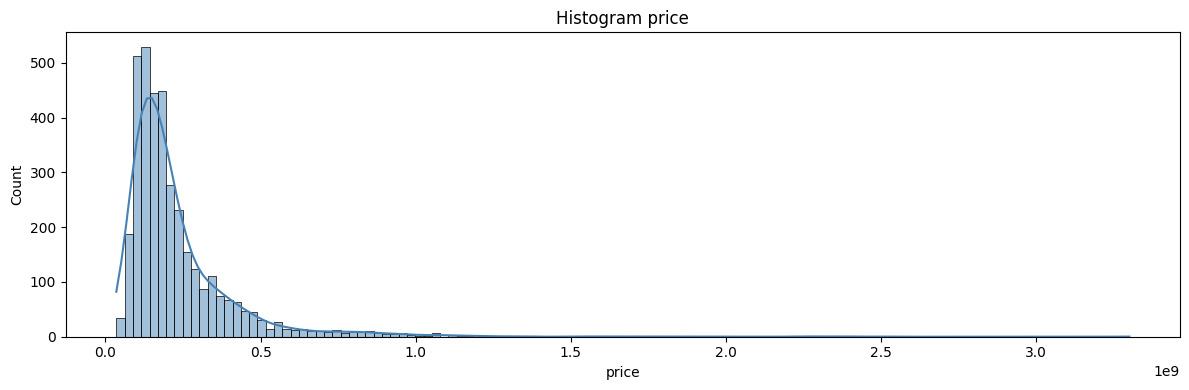

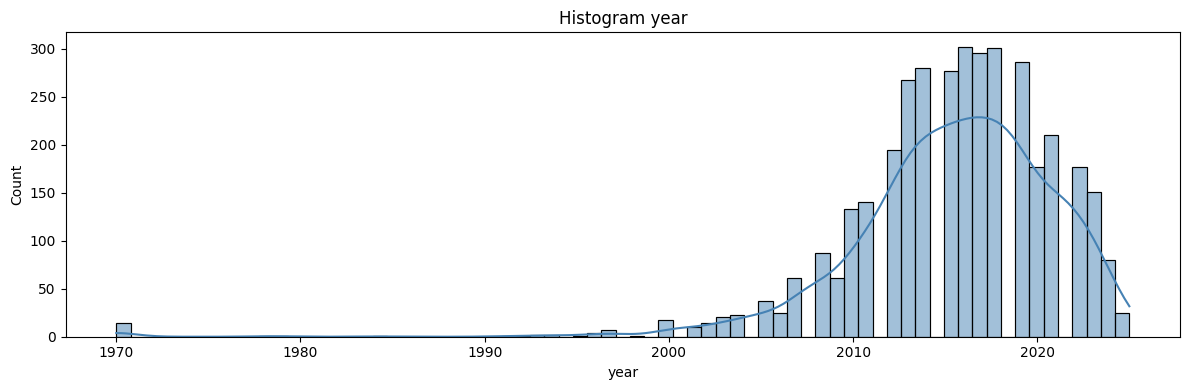

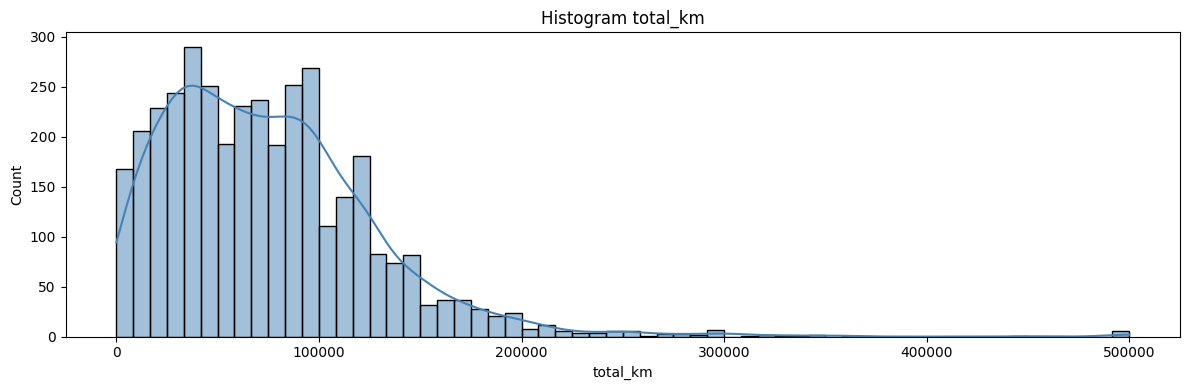

In [415]:
# Histogram — Numerikal
num_features_eda = ['price'] + numerical_features

for col in num_features_eda:
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.histplot(df[col].dropna(), kde=True, color='steelblue', ax=ax)
    ax.set_title(f'Histogram {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

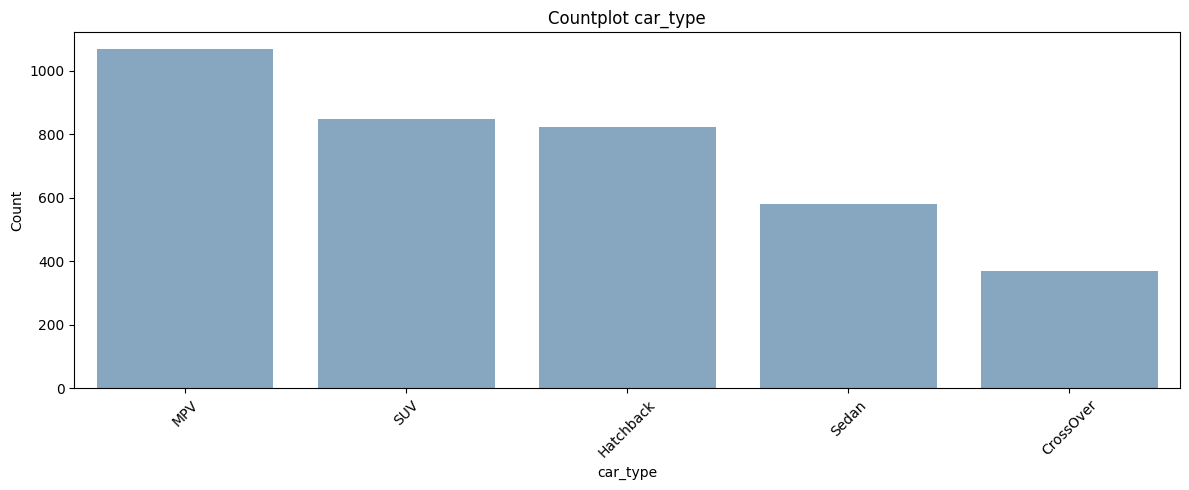

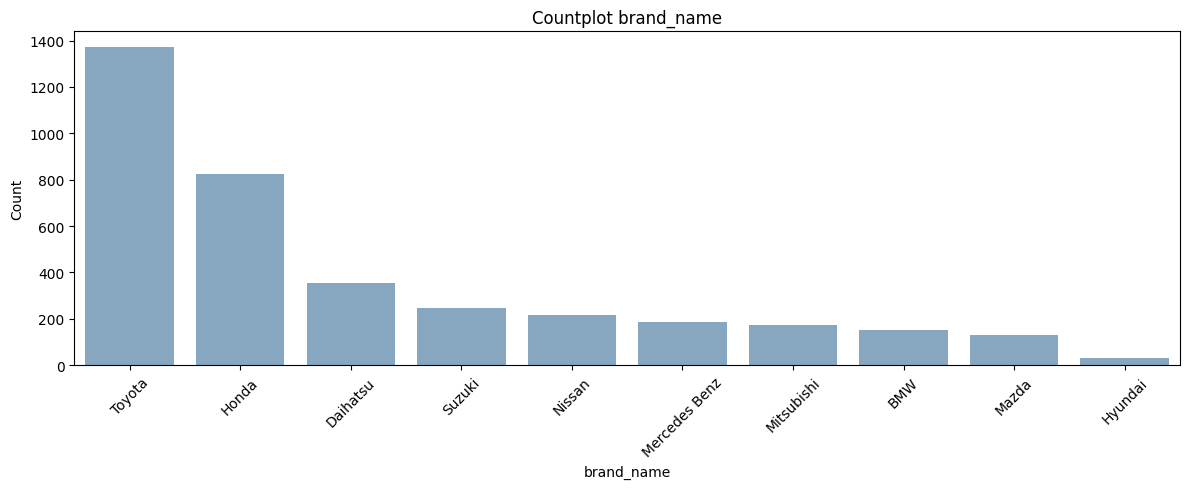

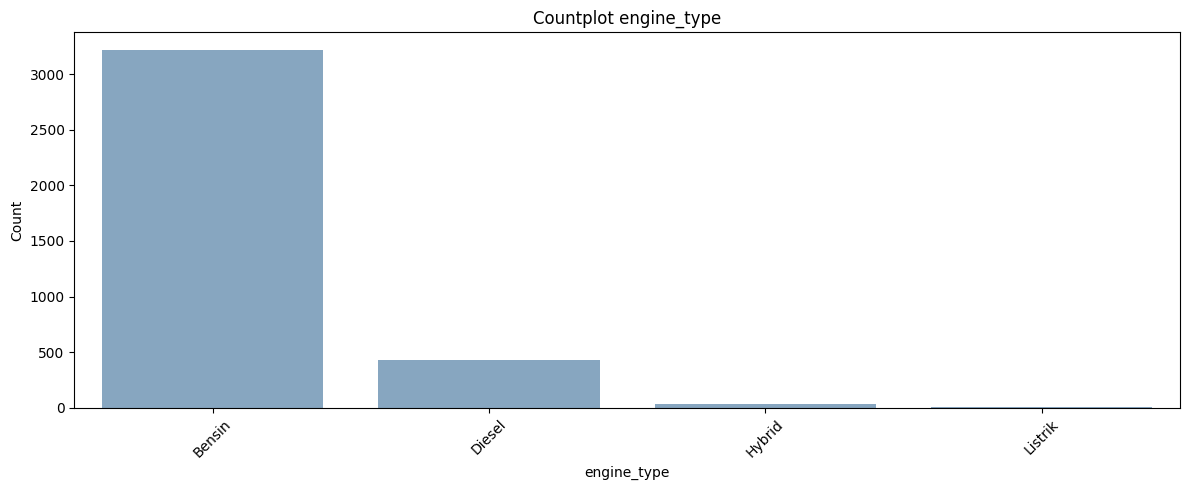

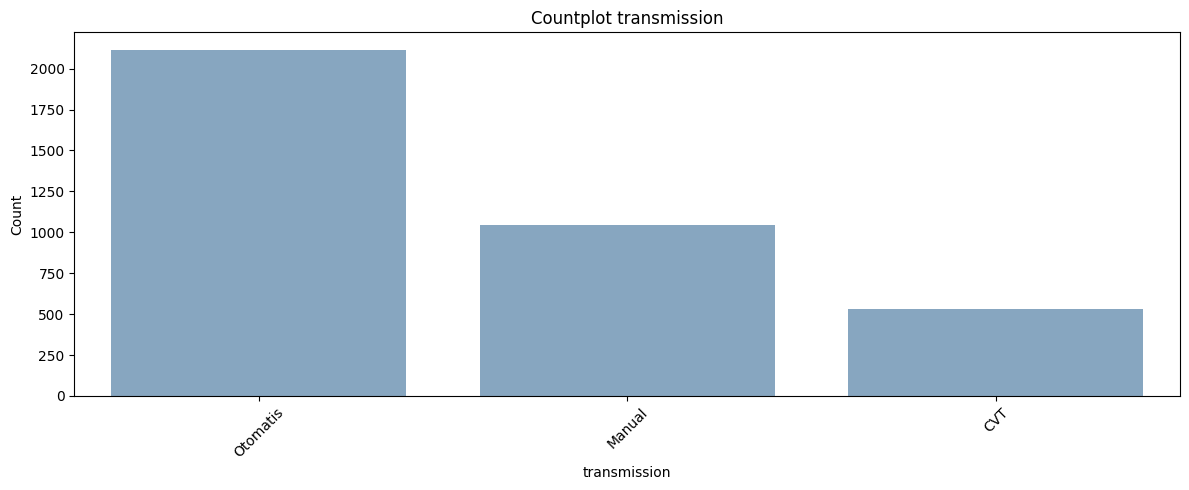

In [416]:
# Countplot — Kategorikal (skip model, model_type & location karena high-cardinality)
countplot_cols = [c for c in categorical_features if c not in ['model', 'model_type', 'location']]

for col in countplot_cols:
    fig, ax = plt.subplots(figsize=(12, 5))
    order   = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, color='steelblue', alpha=0.7, ax=ax)
    ax.set_title(f'Countplot {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

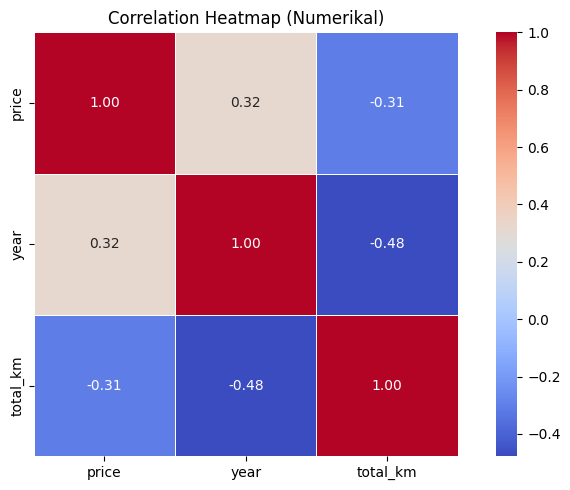

In [417]:
# Heatmap Korelasi
plt.figure(figsize=(8, 5))
corr = df[['price'] + numerical_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Numerikal)')
plt.tight_layout()
plt.show()

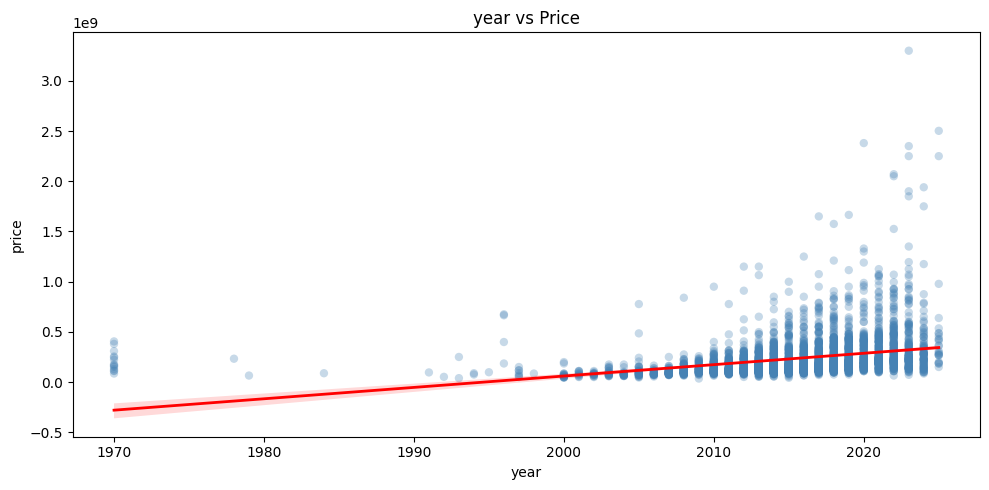

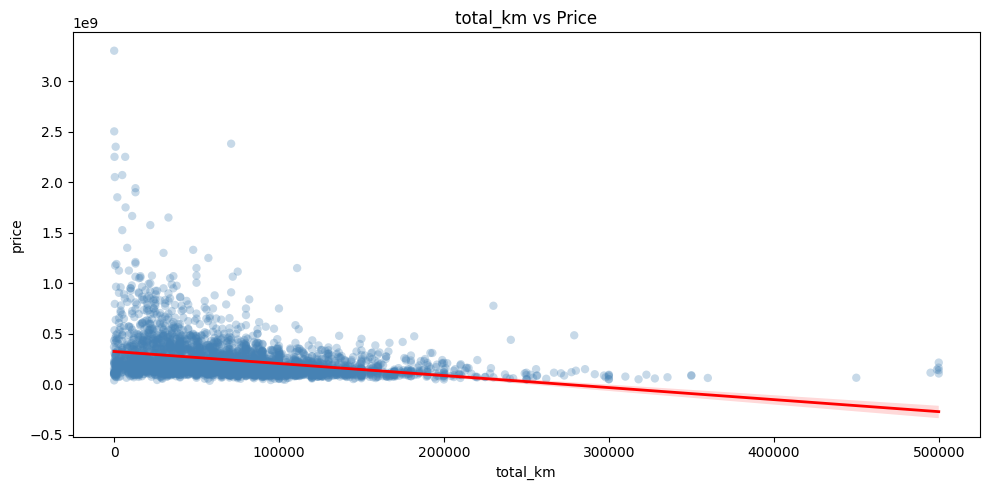

In [418]:
# Scatterplot — Numerikal vs Price
for col in numerical_features:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.regplot(
        data=df, x=col, y='price',
        scatter_kws={'alpha': 0.3, 'color': 'steelblue', 'edgecolors': 'none'},
        line_kws={'color': 'red', 'linewidth': 2},
        ax=ax
    )
    ax.set_title(f'{col} vs Price')
    plt.tight_layout()
    plt.show()

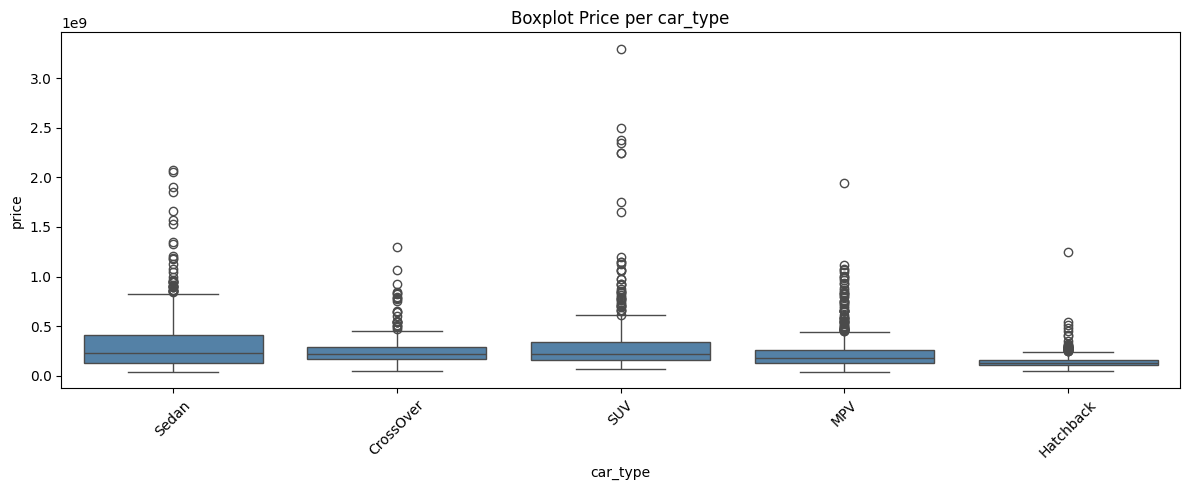

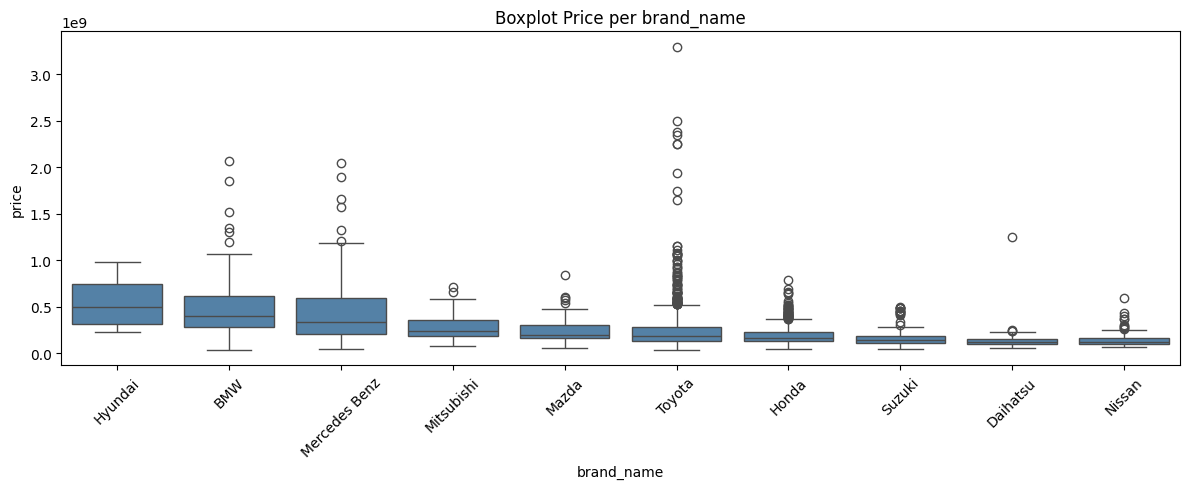

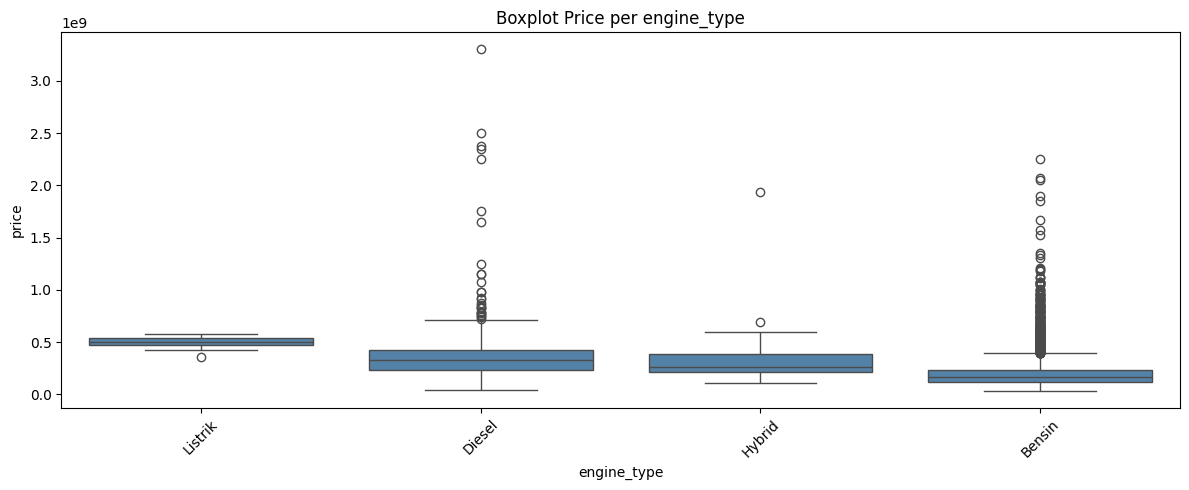

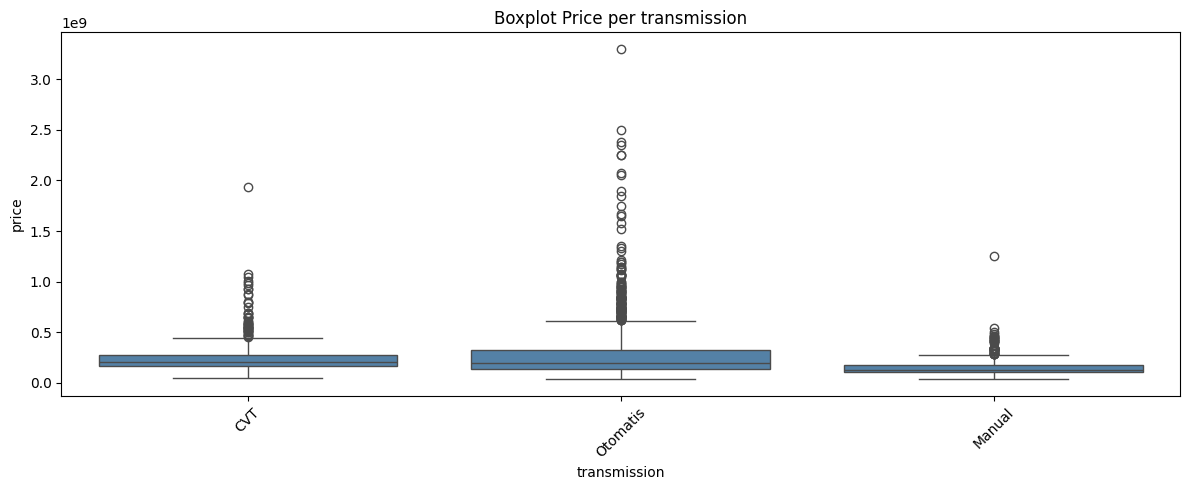

In [419]:
# Boxplot — Kategorikal vs Price (skip model, model_type & location karena high-cardinality)
boxplot_cols = [c for c in categorical_features if c not in ['model', 'location']]

for col in boxplot_cols:
    order  = df.groupby(col)['price'].median().sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=df, x=col, y='price', order=order, color='steelblue', ax=ax)
    ax.set_title(f'Boxplot Price per {col}')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## 4. Train-Test Split
> ⚠️ **Split dilakukan SEBELUM preprocessing apapun** untuk mencegah data leakage.

In [420]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

X_train : (2951, 8)
X_test  : (738, 8)
y_train : (2951,)
y_test  : (738,)


In [421]:
# Pisahkan kolom numerik dan kategorikal
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f'Numerikal : {num_cols}')
print(f'Kategorikal: {cat_cols}')

Numerikal : ['year', 'total_km']
Kategorikal: ['car_type', 'brand_name', 'model', 'location', 'engine_type', 'transmission']


## 6. Encoding Kategorikal
> Pilih salah satu metode encoding di bawah sesuai kebutuhan.

In [422]:
# === PILIHAN A: One Hot Encoding ===
X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)

# Samakan kolom train & test (antisipasi kategori yang tidak muncul di test)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print('=== Preview setelah One Hot Encoding ===')
print(f'Jumlah kolom: {X_train_enc.shape[1]}')
X_train_enc.head()

=== Preview setelah One Hot Encoding ===
Jumlah kolom: 125


,year,total_km,car_type_Hatchback,car_type_MPV,car_type_SUV,car_type_Sedan,brand_name_Daihatsu,brand_name_Honda,brand_name_Hyundai,brand_name_Mazda,...,location_Tangerang,location_Tangerang Selatan,location_Tegal,location_Unknown,location_Yogyakarta,engine_type_Diesel,engine_type_Hybrid,engine_type_Listrik,transmission_Manual,transmission_Otomatis
1011,2012,135000.0,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1178,2023,24000.0,False,False,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
96,2020,40000.0,False,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
43,2011,156000.0,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2592,2016,79000.0,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [423]:
# === PILIHAN B: Label Encoding (untuk kolom ordinal) ===
# Aktifkan sel ini jika ingin pakai Label Encoding

# label_cols = ['transmission', 'engine_type']  # ganti sesuai kebutuhan
# le = LabelEncoder()

# for col in label_cols:
#     X_train_enc[col] = le.fit_transform(X_train[col].astype(str))
#     X_test_enc[col]  = le.transform(X_test[col].astype(str))

In [424]:
# === PILIHAN C: Target Encoding (untuk kolom high-cardinality seperti model, brand) ===
# pip install category_encoders jika belum ada

# import category_encoders as ce
# target_cols = ['model', 'brand_name', 'model_type']
# encoder = ce.TargetEncoder(cols=target_cols)
# X_train_enc[target_cols] = encoder.fit_transform(X_train[target_cols], y_train)  # fit pada train
# X_test_enc[target_cols]  = encoder.transform(X_test[target_cols])                # transform saja pada test

## 7. Scaling Numerikal
> `fit_transform` hanya pada train, `transform` saja pada test.

In [425]:
# === PILIHAN A: Standard Scaler ===
scaler = StandardScaler()
X_train_enc[num_cols] = scaler.fit_transform(X_train_enc[num_cols])  # fit + transform train
X_test_enc[num_cols]  = scaler.transform(X_test_enc[num_cols])       # transform saja test

print('=== Preview setelah Standard Scaler ===')
X_train_enc.head()

=== Preview setelah Standard Scaler ===


,year,total_km,car_type_Hatchback,car_type_MPV,car_type_SUV,car_type_Sedan,brand_name_Daihatsu,brand_name_Honda,brand_name_Hyundai,brand_name_Mazda,...,location_Tangerang,location_Tangerang Selatan,location_Tegal,location_Unknown,location_Yogyakarta,engine_type_Diesel,engine_type_Hybrid,engine_type_Listrik,transmission_Manual,transmission_Otomatis
1011,-0.582784,1.146609,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1178,1.285450,-0.958411,False,False,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
96,0.775932,-0.654985,False,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
43,-0.752623,1.544856,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2592,0.096574,0.084617,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [426]:
# === PILIHAN B: MinMax Scaler ===
# Aktifkan jika ingin pakai MinMax

# scaler = MinMaxScaler()
# X_train_enc[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
# X_test_enc[num_cols]  = scaler.transform(X_test_enc[num_cols])

## 8. Modeling

In [427]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)

    print(f'=== {name} ===')
    print(f'MAE  : {mae:,.0f}')
    print(f'RMSE : {rmse:,.0f}')
    print(f'R²   : {r2:.4f}')
    print()
    return model, pred

In [428]:
rf_model,    rf_pred    = evaluate_model('Random Forest',     RandomForestRegressor(n_estimators=100, random_state=42), X_train_enc, y_train, X_test_enc, y_test)
lr_model,    lr_pred    = evaluate_model('Linear Regression', LinearRegression(),                                        X_train_enc, y_train, X_test_enc, y_test)
knn_model,   knn_pred   = evaluate_model('KNN Regressor',     KNeighborsRegressor(n_neighbors=5),                       X_train_enc, y_train, X_test_enc, y_test)
svr_model, svr_pred = evaluate_model('SVR',               SVR(kernel='rbf', C=1.0, epsilon=0.1),                    X_train_enc, y_train, X_test_enc, y_test)

=== Random Forest ===
MAE  : 36,633,079
RMSE : 77,920,798
R²   : 0.8882

=== Linear Regression ===
MAE  : 63,333,000
RMSE : 127,329,130
R²   : 0.7014

=== KNN Regressor ===
MAE  : 43,796,135
RMSE : 93,145,586
R²   : 0.8402

=== SVR ===
MAE  : 117,988,047
RMSE : 242,321,734
R²   : -0.0815



## 11. Simpan Model & Scaler

In [429]:
# ============================================================
# PILIH model dan scaler yang ingin disimpan ke pickle
# Ganti nilai di bawah sesuai keinginan, lalu jalankan cell ini
# ============================================================

selected_model  = rf_model   # pilihan: rf_model | lr_model | knn_model | svr_model
selected_scaler = scaler     # scaler yang sudah di-fit di Section 7

print(f'Model  : {selected_model.__class__.__name__}')
print(f'Scaler : {selected_scaler.__class__.__name__}')

Model  : RandomForestRegressor
Scaler : StandardScaler


In [430]:
import pickle

with open('model.pickle', 'wb') as f:
    pickle.dump(selected_model, f)

with open('scaler.pickle', 'wb') as f:
    pickle.dump(selected_scaler, f)

with open('columns.pickle', 'wb') as f:
    pickle.dump(list(X_train_enc.columns), f)

print(f'✅ model.pickle   — {selected_model.__class__.__name__}')
print(f'✅ scaler.pickle  — {selected_scaler.__class__.__name__}')
print(f'✅ columns.pickle — {len(X_train_enc.columns)} kolom')

✅ model.pickle   — RandomForestRegressor
✅ scaler.pickle  — StandardScaler
✅ columns.pickle — 125 kolom
